In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import lag_plot, autocorrelation_plot

import seaborn as sns
from scipy.optimize import curve_fit

# sns.set_theme("talk")

In [2]:
def linear_model(t, a, b):

    return a* t + b

def cyclic_model(t, a, k, b):
    return a*np.cos(k * t + b)    

def exp_model(t, a, b):

    return a * np.exp( - b *t)

In [13]:
rng = np.random.default_rng()

t = np.linspace(0, 10, 100)
y_noise = rng.normal(0.0, 1.0, len(t))

y_lin = linear_model(t, -2.0, 3.0)
y_cos = cyclic_model(t, 1.0, 2, -np.pi/2)
y_exp = exp_model(t, 1.0, 0.8)

sct_args = {"s" : 50, "c" : "g", "ec" : 'k'}

y_data_lin = pd.Series(y_lin, name='Linear')
x_data = pd.Series(t, name = 'Time')

data = pd.concat(
    [x_data,
    pd.Series(y_lin, name = "Linear"), # Add the linear data to the dataframe
    pd.Series(y_cos, name = "Cyclic"), # Add the cyclic model to the dataframe
    pd.Series(y_noise, name = "Random Noise"), # Add the noise model to the dataframe
    pd.Series(y_exp, name = "Exponential") # Add the exponetial  model to the dataframe
    ], 
                axis = 1)

data.head()

,Time,Linear,Cyclic,Random Noise,Exponential
0,0.00000,3.000000,6.123234e-17,0.355787,1.000000
1,0.10101,2.797980,2.006489e-01,0.405008,0.922371
2,0.20202,2.595960,3.931366e-01,-0.358724,0.850768
3,0.30303,2.393939,5.696341e-01,-0.093043,0.784723
4,0.40404,2.191919,7.229626e-01,0.181733,0.723806


[Text(0.5, 1.0, 'Lag plot of Linear model')]

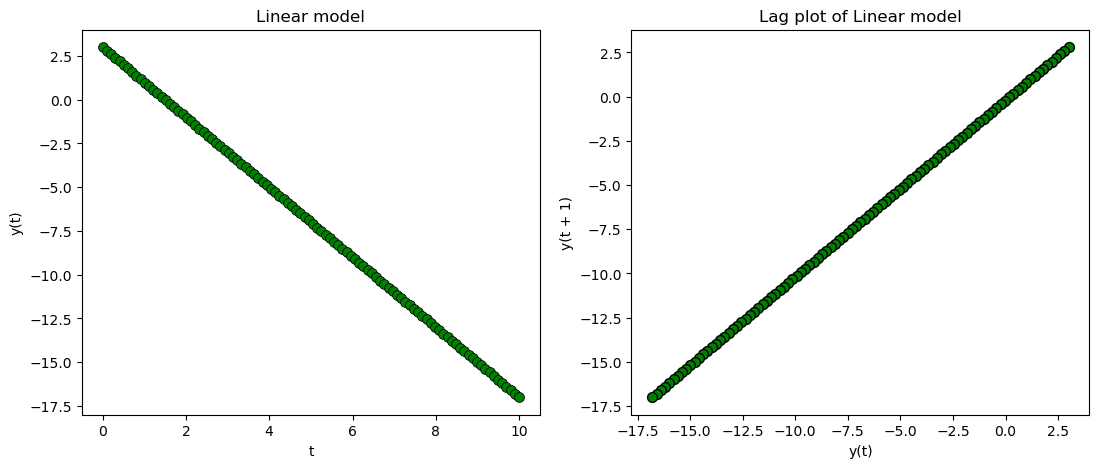

In [14]:
fig, ax = plt.subplots(1,2, figsize = (13,5))
sns.scatterplot(data = data, x = "Time", y = "Linear",  **sct_args, ax= ax[0])
ax[0].set(xlabel = 't', ylabel = 'y(t)', title = 'Linear model')
lag_plot(data["Linear"], ax=ax[1], **sct_args)
ax[1].set( title = 'Lag plot of Linear model')
# autocorrelation_plot(data["Linear"], ax = ax[2])

[Text(0.5, 1.0, 'Lag plot of Sinusoidal model')]

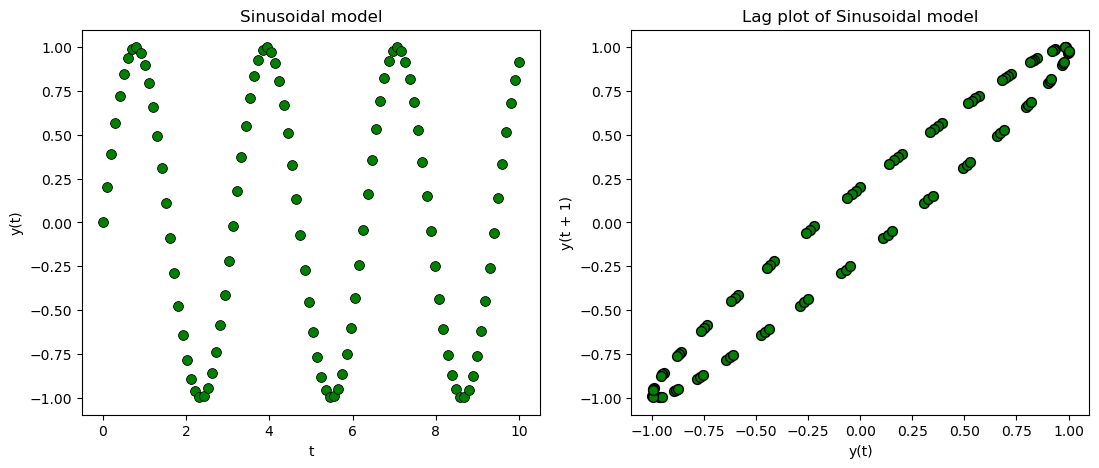

In [5]:
# Cyclic model

fig, ax = plt.subplots(1,2, figsize = (13,5))
sns.scatterplot(data = data, x = "Time", y = "Cyclic",  **sct_args, ax= ax[0])
ax[0].set(xlabel = 't', ylabel = 'y(t)', title = 'Sinusoidal model')
lag_plot(data["Cyclic"], ax=ax[1], **sct_args)
ax[1].set( title = 'Lag plot of Sinusoidal model')
# autocorrelation_plot(data["Cyclic"], c = 'g', ax = ax[2])

[Text(0.5, 1.0, 'Lag plot of Noise model')]

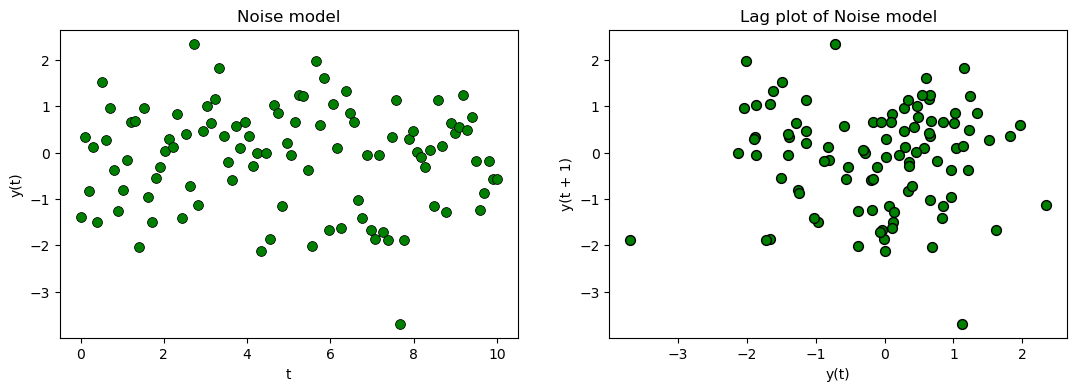

In [6]:
# Noise model
fig, ax = plt.subplots(1,2, figsize = (13,4))
sns.scatterplot(data = data, x = "Time", y = "Random Noise", **sct_args, ax= ax[0])
ax[0].set(xlabel = 't', ylabel = 'y(t)', title = 'Noise model')
lag_plot(data["Random Noise"].iloc[::1], ax=ax[1], **sct_args)
ax[1].set( title = 'Lag plot of Noise model')
# autocorrelation_plot(data["Random Noise"], ax =ax[2])

[None, None, Text(0.5, 1.0, 'Lag plot of Exponential model')]

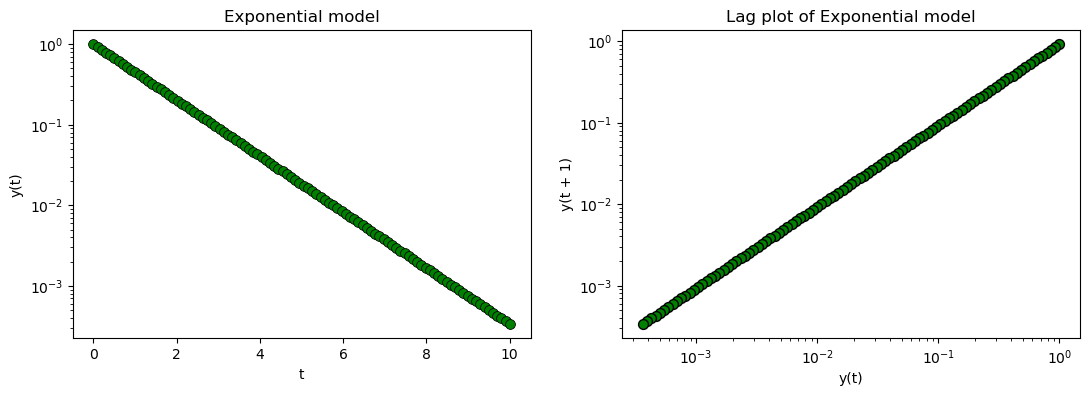

In [7]:
# Exponential model
fig, ax = plt.subplots(1,2, figsize = (13,4))
sns.scatterplot(data = data, x = "Time", y = "Exponential",  **sct_args, ax= ax[0])
ax[0].set(xlabel = 't',yscale = 'log', ylabel = 'y(t)', title = 'Exponential model')
lag_plot(data["Exponential"].iloc[::1], ax=ax[1], **sct_args)
ax[1].set(xscale = 'log',  yscale = 'log', title = 'Lag plot of Exponential model')
# autocorrelation_plot(data["xExponential"], ax = ax[2])

## Autoregression on Biden's approval

In [8]:

# We're going to read in the data, but then only look at one pollster source, the Ipsos polls
data_2023 = pd.read_csv("../Day-14/biden_ratings_2023.csv")
data_2023["end_date"] = pd.to_datetime(data_2023['end_date'], format='%m/%d/%y')
data_2023.sort_values(by = "end_date", ascending = True, inplace = True)

#  Create a new array containing the days since the first row
time_values = (data_2023['end_date'] - data_2023['end_date'].iloc[0]).dt.days

# What does this do? Google it!
data = pd.concat([data_2023, time_values.rename("Time")], axis = 1)

# Masking
ipsos = data[ data["pollster"] == "Ipsos" ]

# Drop the first value, because it is a duplicate. Comment this line to see what it does,
ipsos.drop(4038,inplace = True)

# Drop unwanted columns
ipsos = ipsos[["end_date", "Time", "yes", "no"]]
ipsos.reset_index(inplace = True)
ipsos.head(10)

/var/folders/cq/63hr2pgs2m1_z45dj0_n28wm0000gp/T/ipykernel_33168/281037201.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  ipsos.drop(4038,inplace = True)


,index,end_date,Time,yes,no
0,4039,2021-01-21,0,57.00,32.00
1,3977,2021-02-03,13,57.46,34.28
2,3958,2021-02-10,20,57.42,35.18
3,3929,2021-02-18,28,55.50,35.95
4,3901,2021-02-25,35,56.54,37.44
5,3871,2021-03-04,42,57.86,34.53
6,3843,2021-03-11,49,53.76,39.11
7,3821,2021-03-18,56,58.74,35.39
8,3790,2021-03-25,63,53.46,40.66
9,3763,2021-04-01,70,54.00,40.80


[Text(0.5, 1.0, 'Lag Plot')]

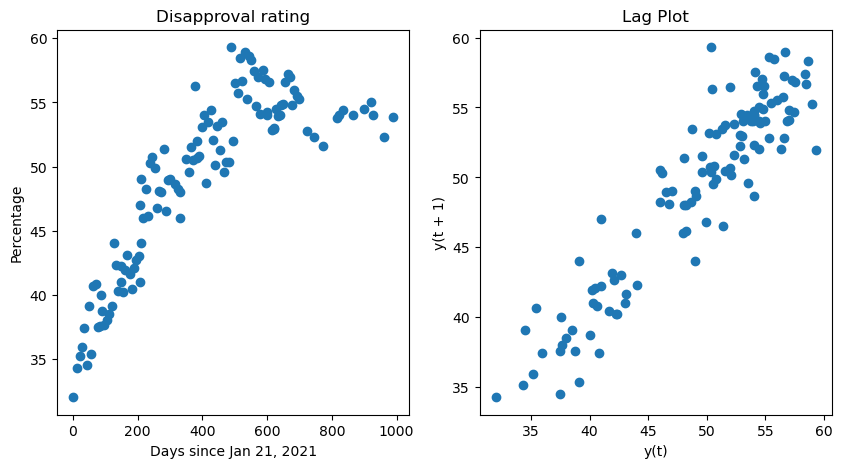

In [9]:
# Just looking at the data to start 
fig, ax = plt.subplots(1,2, figsize = (10,5))
ax[0].scatter(ipsos["Time"],ipsos["no"], marker = 'o')
lag_plot(ipsos["no"], ax= ax[1])
ax[0].set(title = "Disapproval rating", xlabel = "Days since Jan 21, 2021", ylabel = 'Percentage')
ax[1].set(title = 'Lag Plot')

[Text(0.5, 1.0, 'Disapproval rating'),
 Text(0.5, 0, 'Days since Jan 21, 2021'),
 Text(0, 0.5, 'Percentage')]

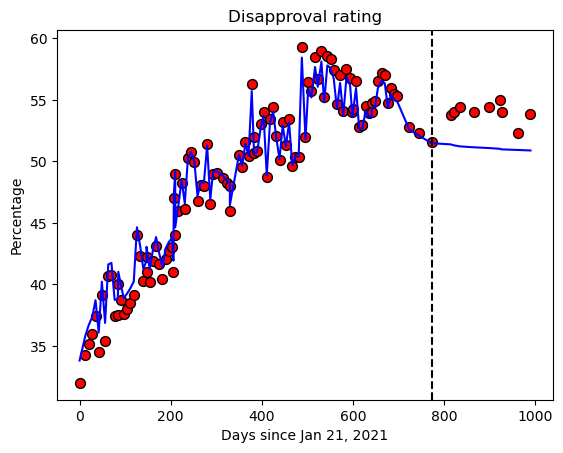

In [10]:
# MASK
day400_mask = ipsos["Time"] <= 800
ipsos_400 = ipsos[day400_mask]

# Do the autoregression
popt, _ = curve_fit(linear_model, 
                    ipsos_400['no'].iloc[0:-1], # Y(t)
                    ipsos_400['no'].iloc[1:]   # Y(t +1)
                   )
# Make a prediction of the first 400 days
auto_reg = linear_model(
    ipsos_400['no'].values, # x is my Y now!
    *popt)

# Select the next 400 days
ipsos_rest = ipsos[ ~day400_mask] 
# Predict the next 400 days, using the new prediction 
for i, t in enumerate(ipsos_rest["Time"]):
    # This is the
    auto_reg = np.append(auto_reg, 
                         linear_model(auto_reg[-1],*popt))
    # print(len(auto_reg))

fig, ax = plt.subplots(1,1,)
ax.scatter(ipsos["Time"],ipsos['no'], s = 50, color='r', ec = 'k', label='Original Data')
ax.plot(ipsos["Time"], auto_reg, 'b', label = 'Autoregressive model')
ax.axvline(ipsos_400["Time"].iloc[-1], ls = '--', c = 'k')
ax.set(title = "Disapproval rating", xlabel = "Days since Jan 21, 2021", ylabel = 'Percentage')